In [1]:
# CELL 1: Imports et chargement des donnees pretraitees

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des jeux pretraites (issus de l'etape 2)
X_train = pd.read_csv('../data/output/X_train_prep.csv')
X_test = pd.read_csv('../data/output/X_test_prep.csv')
# squeeze() : conversion des cibles (une seule colonne) en Series
y_train = pd.read_csv('../data/output/y_train.csv').squeeze()
y_test = pd.read_csv('../data/output/y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (113754, 66) | X_test: (28439, 66)
y_train: (113754,) | y_test: (28439,)


In [2]:
# CELL 2: Entrainement des trois modeles (gestion du desequilibre)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Ratio de desequilibre pour XGBoost : negatifs / positifs (calcule sur le train)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

# Trois modeles, chacun avec sa gestion du desequilibre de classes
modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                             random_state=42, n_jobs=-1),
}

# Entrainement puis prediction (labels + probabilites) sur le jeu de test
predictions = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    predictions[nom] = {'y_pred': y_pred, 'y_proba': y_proba}
    print(f"{nom} : entraine.")

scale_pos_weight = 3.4606


LogisticRegression : entraine.


RandomForest : entraine.


XGBoost : entraine.


In [3]:
# CELL 3: Tableau comparatif des performances

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

# Metriques sur le jeu de test (F1 = metrique principale car classes desequilibrees)
lignes = []
for nom in modeles:
    y_pred = predictions[nom]['y_pred']
    y_proba = predictions[nom]['y_proba']
    lignes.append({
        'Modele': nom,
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
    })

comparaison = pd.DataFrame(lignes).sort_values('F1', ascending=False).reset_index(drop=True)
print("Comparaison des performances (jeu de test), triee par F1 decroissant:")
print(comparaison.round(4).to_string(index=False))

Comparaison des performances (jeu de test), triee par F1 decroissant:
            Modele     F1  ROC_AUC  Precision  Recall  Accuracy
           XGBoost 0.6594   0.8882     0.5736  0.7754    0.8205
      RandomForest 0.6563   0.8856     0.6697  0.6435    0.8489
LogisticRegression 0.6173   0.8588     0.5165  0.7671    0.7868


Figure sauvegardee: figures/etape3_01_matrices_confusion.png


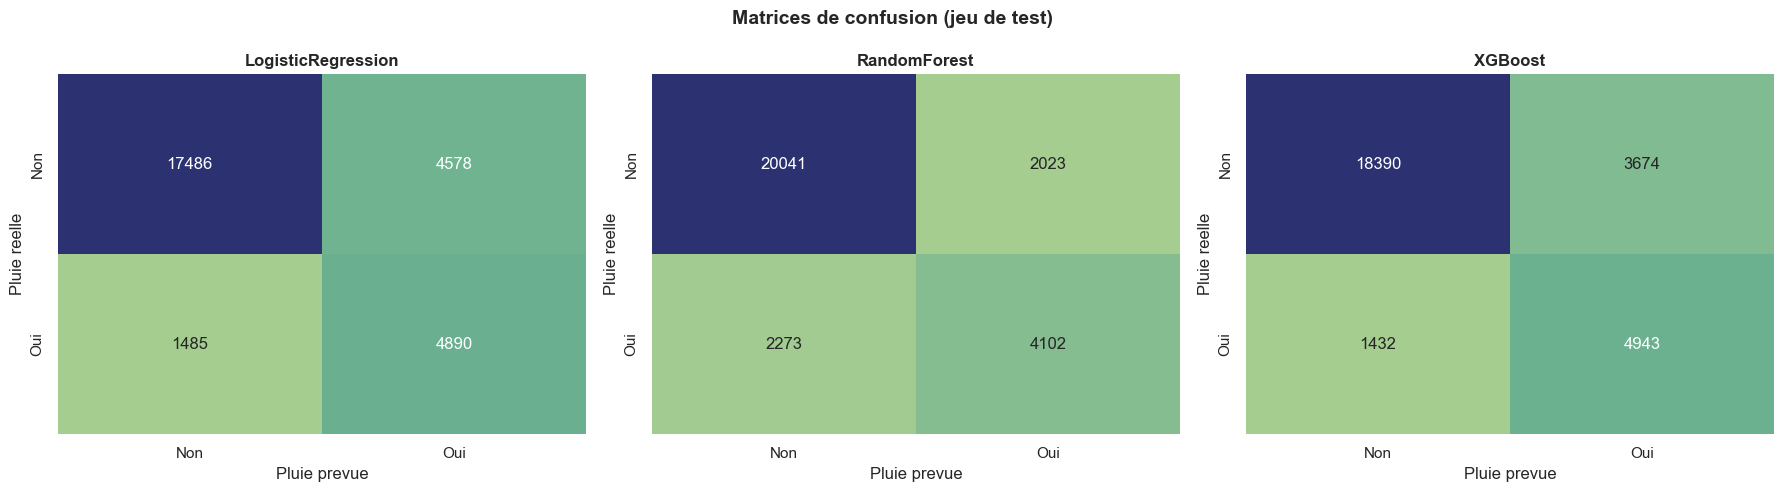

In [4]:
# CELL 4: Matrices de confusion

from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nom in zip(axes, modeles):
    cm = confusion_matrix(y_test, predictions[nom]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', cbar=False, ax=ax)
    ax.set_title(nom, fontsize=12, fontweight='bold')
    ax.set_xlabel("Pluie prevue")
    ax.set_ylabel("Pluie reelle")
    ax.set_xticklabels(['Non', 'Oui'])
    ax.set_yticklabels(['Non', 'Oui'])

fig.suptitle("Matrices de confusion (jeu de test)", fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/etape3_01_matrices_confusion.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape3_01_matrices_confusion.png")
plt.show()

Figure sauvegardee: figures/etape3_02_courbes_roc.png


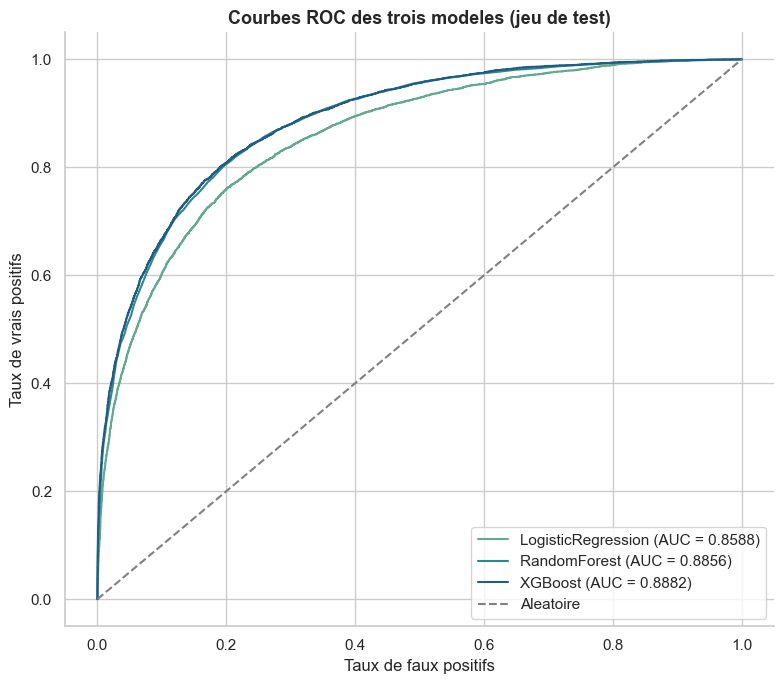

In [5]:
# CELL 5: Courbes ROC superposees

from sklearn.metrics import roc_curve

sns.set_theme(style="whitegrid", context="notebook")
couleurs = sns.color_palette("crest", len(modeles))

fig, ax = plt.subplots(figsize=(8, 7))
for nom, couleur in zip(modeles, couleurs):
    y_proba = predictions[nom]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=couleur, label=f"{nom} (AUC = {auc:.4f})")

# Ligne de reference du classifieur aleatoire
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatoire')
ax.set_title("Courbes ROC des trois modeles (jeu de test)", fontsize=13, fontweight='bold')
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape3_02_courbes_roc.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape3_02_courbes_roc.png")
plt.show()

In [8]:
# CELL 6: Sauvegarde des trois modeles entraines

import joblib
import os

# Recuperation des modeles entraines depuis le dictionnaire (CELL 2)
logreg = modeles['LogisticRegression']
rf = modeles['RandomForest']
xgb_model = modeles['XGBoost']

# Creation du dossier models/ a la racine du projet si necessaire
os.makedirs('../models', exist_ok=True)

# Sauvegarde : joblib pour les modeles sklearn, format natif JSON pour XGBoost
joblib.dump(logreg, '../models/logreg.joblib')
joblib.dump(rf, '../models/random_forest.joblib')
xgb_model.save_model('../models/xgboost.json')

print("Modeles sauvegardes:")
print(" - models/logreg.joblib")
print(" - models/random_forest.joblib")
print(" - models/xgboost.json")

Modeles sauvegardes:
 - models/logreg.joblib
 - models/random_forest.joblib
 - models/xgboost.json
